# 01 — EDA: volume geometry, class balance, and multi-site checks

Sections are numbered to match the notebook itself. Questions 1-7 come from the
2026-09-07 project discussion, grounded in the prior-art scan
(`structuring-ml-projects` step 0, logged in `RESOURCES.md`); 8-9 were added
2026-09-08 after a coverage review against `problem_description.txt`; 10-12 and
the 6c/6d subsections were added 2026-09-08 after a methodology review.

1. Volume shape and voxel spacing across the 1362 training exams
2. Class balance in `train_labels.csv`
3. (shape, spacing) clusters as a scanner proxy — confound check
   - 3a. A less-fragmented header-derived site proxy, with a significance test
4. NIfTI orientation, axis convention, and **affine obliquity**
5. Background/intensity level, to calibrate background removal
6. Striatum location and left-right asymmetry
   - 6a. Striatum location & size (physical-volume mask, results in mm)
   - 6b. **Signed** left-right asymmetry index, aggregated by class
   - 6c. Per-site-proxy breakdown of the intensity table
   - 6d. Single-feature signal ranking (AUC / log loss) for pixel features
7. Field of view (shape × spacing) and the resampling target
8. Data integrity: `train_labels.csv` rows vs. `.nii.gz` files
9. Smoke-test set geometry **and orientation** compatibility
10. Evaluation reference point: the constant-prediction baseline log loss
11. How much log loss is available from metadata alone (shortcut check)
12. Duplicate/repeat-patient fingerprint check

**Note on data handling:** cells that read only NIfTI header metadata (shape,
spacing, affine, dtype, qform/sform) or aggregate label counts are separated
from cells that load actual pixel data. The latter are meant to be run and
inspected by you, not by Claude, per the project's AI-assistant data-handling
rule (see `README.md`). Cells that need pixel data are marked **[RUN ME]**.

**Note on findings:** each section's post-code markdown cell states what we
looked for, why, the source backing the method, what we actually found, and
the decision/next step it informs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import config

%matplotlib inline

## 1. Volume geometry: shape and voxel spacing (header metadata only)

`nib.load()` is lazy — `.shape` and `.header.get_zooms()` read only the header,
not the pixel array, so this cell never touches actual scan intensities.

In [2]:
def scan_geometry(nifti_dir: Path) -> pd.DataFrame:
    """Read shape and voxel spacing from every NIfTI header in nifti_dir.

    Header-only (lazy load) — does not read pixel data.
    """
    rows = []
    for path in sorted(nifti_dir.glob("*.nii.gz")):
        img = nib.load(str(path))
        zooms = img.header.get_zooms()
        rows.append(
            {
                "uid": path.name.removesuffix(".nii.gz"),
                "shape": img.shape,
                "spacing": tuple(round(float(z), 3) for z in zooms),
            }
        )
    return pd.DataFrame(rows)


geometry_df = scan_geometry(config.NIFTI_DIR)
print(f"{len(geometry_df)} volumes scanned")
geometry_df.head()

1362 volumes scanned


,uid,shape,spacing
0,01nouhtc,"(128, 128, 90)","(1.468, 1.468, 1.5)"
1,0224wk0y,"(128, 128, 38)","(3.895, 3.895, 3.9)"
2,049enulq,"(128, 128, 45)","(1.578, 1.578, 3.0)"
3,04x0qzfh,"(256, 256, 256)","(2.46, 2.46, 2.46)"
4,05xt54fn,"(256, 256, 256)","(2.46, 2.46, 2.46)"


Distinct shapes: 66
shape
(256, 256, 256)    460
(128, 128, 128)    295
(128, 128, 87)     143
(128, 128, 45)      46
(128, 128, 43)      38
(128, 128, 39)      33
(128, 128, 40)      29
(128, 128, 42)      28
(128, 128, 90)      26
(128, 128, 41)      26
(128, 128, 38)      25
(128, 128, 49)      21
(128, 128, 37)      19
(128, 128, 36)      16
(128, 128, 44)      12
(128, 128, 52)       8
(128, 128, 55)       7
(134, 134, 112)      7
(144, 144, 112)      7
(140, 140, 112)      6
Name: count, dtype: int64

Distinct spacings: 52
spacing
(2.46, 2.46, 2.46)       528
(3.895, 3.895, 3.9)      254
(2.3, 2.3, 2.3)          207
(2.398, 2.398, 2.398)    143
(3.895, 3.895, 3.895)     71
(3.296, 3.296, 3.3)       26
(1.468, 1.468, 1.5)       25
(3.305, 3.305, 3.0)       13
(2.0, 2.0, 4.0)           10
(3.591, 3.591, 3.591)      9
(4.42, 4.42, 4.42)         9
(2.398, 2.398, 2.4)        6
(1.654, 1.654, 3.0)        5
(1.578, 1.578, 3.0)        3
(1.619, 1.619, 3.0)        3
(1.64, 1.64, 3.0)     

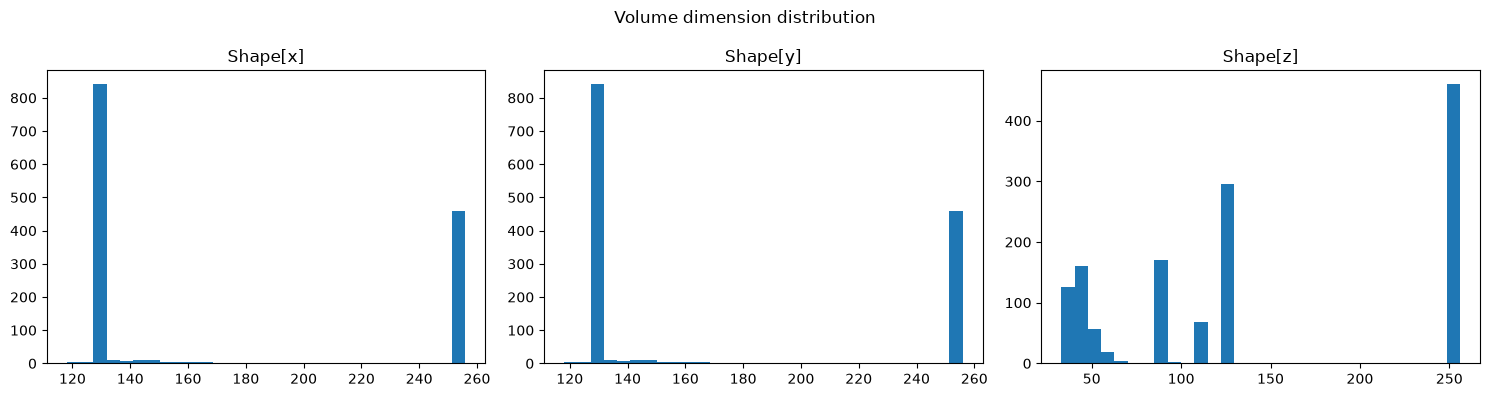

In [3]:
shape_counts = geometry_df["shape"].value_counts()
spacing_counts = geometry_df["spacing"].value_counts()

print("Distinct shapes:", len(shape_counts))
print(shape_counts.head(20))
print()
print("Distinct spacings:", len(spacing_counts))
print(spacing_counts.head(20))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, axis_name in enumerate(["x", "y", "z"]):
    axes[i].hist(geometry_df["shape"].apply(lambda s: s[i]), bins=30)
    axes[i].set_title(f"Shape[{axis_name}]")
fig.suptitle("Volume dimension distribution")
plt.tight_layout()
plt.show()

**What we're looking for:** the real distribution of shape and voxel
spacing across the 1362 training volumes.

**Why:** the competition's own problem description explicitly warns that
"images are not all the same size or resolution" and that the pipeline
"should not assume a fixed input shape" (`problem_description.txt`) — we
need to know the actual range before designing the resampling step.

**Source:** `problem_description.txt` (organizers' explicit warning) +
`deep-learning-imaging.md` (criterion for resampling to a common physical
spacing rather than a fixed voxel shape).

**What we found:** 66 distinct shapes and 52 distinct spacings. Dominated
by `(256,256,256)` @ 2.46mm isotropic (460 vols, 33.8%), `(128,128,128)` @
2.3mm (207, 15.2%), and `(128,128,87)` @ 2.398mm (143, 10.5%), plus a long
tail of `(128,128,z)` shapes with varying z at ~3.895mm in-plane spacing.

**Decision / next step:** neither shape nor spacing is fixed, and the
spread is non-trivial (66 combinations) — `data.py` must resample to a
common physical spacing (not a fixed voxel shape) before any cropping, and
the striatum crop must be defined in mm, not in voxels proportional to a
reference shape (confirms Boulkrinat et al. 2025's caveat in
`RESOURCES.md`: their proportional crop is tied to PPMI's fixed
91×109×91 shape, which doesn't apply here).

## 2. Class balance (aggregate label counts only)

Reads `train_labels.csv` but only prints aggregate counts/percentages — no
per-row values are displayed.

Class counts:
 is_pathologic
1.0    747
0.0    615
Name: count, dtype: int64

Class percentages:
 is_pathologic
1.0    54.8
0.0    45.2
Name: proportion, dtype: float64


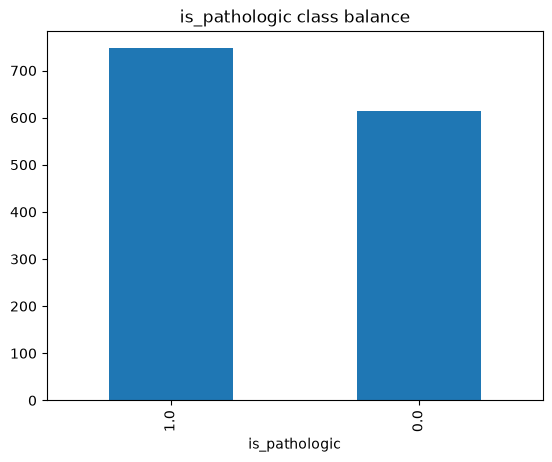

In [4]:
labels_df = pd.read_csv(config.TRAIN_LABELS_PATH)
class_counts = labels_df[config.TARGET_COLUMN].value_counts()
class_pct = labels_df[config.TARGET_COLUMN].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_pct.round(1))

class_counts.plot(kind="bar", title="is_pathologic class balance")
plt.show()

**What we're looking for:** the class balance of `is_pathologic` in the
training set.

**Why:** determines whether loss reweighting (`class_weight`) is needed
and confirms the need for Stratified K-Fold — steps 1-2 of
`structuring-ml-projects`, which require fixing the evaluation strategy
before any feature/model work.

**Source:** `structuring-ml-projects` SKILL.md, step 2 (class-balance
profiling is a required part of EDA) + Boulkrinat et al. 2025, who used
`class_weight="balanced"` on a split that was also class-balanced
(`RESOURCES.md`).

**What we found:** 747 pathological cases (54.8%) vs. 615 normal (45.2%)
— mild imbalance, not severe.

**Decision / next step:** Stratified K-Fold on `is_pathologic` is
mandatory (already decided independently of this result), but the
imbalance is mild — it doesn't by itself justify adding
`class_weight="balanced"` by default. Treat it as an experiment to
validate against the gate (step 6), not a default.

## 3. (shape, spacing) clusters as a scanner proxy — confound check

Still metadata + aggregate label statistics only (group-level target rate,
not per-patient values).

In [5]:
merged_df = geometry_df.merge(labels_df, on="uid", how="inner")
merged_df["scanner_proxy"] = list(zip(merged_df["shape"], merged_df["spacing"]))

proxy_summary = (
    merged_df.groupby("scanner_proxy")[config.TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(columns={"mean": "target_rate"})
    .sort_values("count", ascending=False)
)
print(f"{len(proxy_summary)} distinct (shape, spacing) groups")
proxy_summary.head(20)

134 distinct (shape, spacing) groups


,count,target_rate
scanner_proxy,,
"((256, 256, 256), (2.46, 2.46, 2.46))",460,0.593478
"((128, 128, 128), (2.3, 2.3, 2.3))",207,0.502415
"((128, 128, 87), (2.398, 2.398, 2.398))",143,0.454545
"((128, 128, 128), (3.895, 3.895, 3.895))",70,0.585714
"((128, 128, 43), (3.895, 3.895, 3.9))",37,0.513514
"((128, 128, 39), (3.895, 3.895, 3.9))",33,0.484848
"((128, 128, 40), (3.895, 3.895, 3.9))",29,0.655172
"((128, 128, 42), (3.895, 3.895, 3.9))",28,0.642857
"((128, 128, 41), (3.895, 3.895, 3.9))",25,0.600000


**What we're looking for:** whether the (shape, spacing) groups — used as
a scanner/protocol proxy, since `train_labels.csv` carries no center
column — show a systematically different target rate from one another
(confound).

**Why:** multicenter data (10 French hospitals) with no center/scanner
label. A scanner confound is both a generalization risk and a fold-design
constraint — `structuring-ml-projects` SKILL.md step 2 requires profiling
the target rate per group whenever acquisition metadata is available, and
`deep-learning-imaging.md` ("Multi-site generalization") treats this as a
confound to watch for, not ignore.

**Source:** `structuring-ml-projects` SKILL.md step 2 + `deep-learning-
imaging.md` "Multi-site generalization" + Wenzel et al. 2019 (cited in
`RESOURCES.md`, multi-scanner generalization in DaT-SPECT).

**What we found:** 134 distinct (shape, spacing) groups. The target rate
varies noticeably even among the larger groups — not just small-group
noise: 0.593 in the dominant group (n=460) vs. 0.502 (n=207) vs. 0.455
(n=143), against a global average of 0.548. Groups with n=9-10 swing much
harder (0.33-0.78), which is more likely small-sample noise.

**Decision / next step:** the confound is real in the larger groups →
fold design must account for this proxy (group/stratify by it, or by a
real center id if one can be derived elsewhere) so the target rate isn't
split unevenly across folds.

**Limitation:** the (shape, spacing) proxy is imperfect — the same scanner
can produce several combinations (protocol changes) and different
scanners can share one combination. It doesn't substitute for a real
center id, which isn't available in this dataset.

### 3a. A less-fragmented site proxy, and an actual significance test

Section 3 asserted the confound was "real, not noise" without testing it. Two
problems with the proxy it used:

1. **It over-fragments.** The whole `(128,128,z)@3.895mm` family is almost
   certainly one scanner with a variable axial slab, but (shape, spacing)
   splits it across ~12 groups by `z` alone and then dismisses each as
   small-sample noise. 134 groups also makes any `GroupKFold` structurally
   impossible — the largest group is 34% of the data.
2. **It was never tested.** Below: χ² across groups with n≥20, plus pairwise
   two-proportion z-tests on the three largest groups.

Header-only, so this cell is safe to run without touching pixel data. It also
mines the header fields nobody looked at (`descrip`, `db_name`, `aux_file`,
`intent_name`, `scl_slope`/`scl_inter`, dtype, affine obliquity) for anything
closer to a real centre id.

In [ ]:
from scipy import stats

hdr_rows = []
for path in sorted(config.NIFTI_DIR.glob("*.nii.gz")):
    img = nib.load(str(path))          # lazy: header only, no get_fdata()
    h = img.header
    aff = np.asarray(img.affine, dtype=float)
    rot = aff[:3, :3]
    norms = np.linalg.norm(rot, axis=0)
    norms[norms == 0] = 1.0
    unit = rot / norms
    zooms = tuple(round(float(z), 3) for z in h.get_zooms()[:3])
    hdr_rows.append({
        "uid": path.name.removesuffix(".nii.gz"),
        "inplane": zooms[0],
        "zspacing": round(zooms[2], 2),
        "fov_xy": round(img.shape[0] * zooms[0], 0),
        "dtype": str(h.get_data_dtype()),
        "max_offdiag": float(np.abs(unit - np.diag(np.diag(unit))).max()),
        "descrip": bytes(h["descrip"]).decode("latin-1", "replace").strip("\x00 "),
        "db_name": bytes(h["db_name"]).decode("latin-1", "replace").strip("\x00 "),
        "aux_file": bytes(h["aux_file"]).decode("latin-1", "replace").strip("\x00 "),
    })
hdr_df = pd.DataFrame(hdr_rows)


def inplane_family(v):
    """Collapse near-identical in-plane spacings into one scanner family."""
    for lo, hi, name in [(1.40, 1.50, "~1.47"), (1.50, 1.80, "~1.5-1.8"),
                         (1.99, 2.01, "2.00"), (2.29, 2.31, "2.30"),
                         (2.39, 2.41, "2.398"), (2.45, 2.47, "2.46"),
                         (3.28, 3.32, "~3.30"), (3.58, 3.60, "3.591"),
                         (3.88, 3.90, "3.895"), (4.41, 4.43, "4.42")]:
        if lo <= v < hi:
            return name
    return f"other({v:.3f})"


hdr_df["inplane_family"] = hdr_df["inplane"].apply(inplane_family)
hdr_df["is_oblique"] = hdr_df["max_offdiag"] > 1e-3
hdr_df["site_proxy"] = list(zip(hdr_df["inplane_family"], hdr_df["zspacing"],
                                hdr_df["fov_xy"], hdr_df["dtype"]))

proxy_df = hdr_df.merge(labels_df, on=config.UID_COLUMN, how="inner")

# Are any descriptive header fields usable as a centre id?
for col in ["descrip", "db_name", "aux_file", "dtype"]:
    print(f"{col}: {proxy_df[col].nunique()} distinct ->",
          proxy_df[col].value_counts().head(3).to_dict())


def profile(col, head=12):
    g = (proxy_df.groupby(col)[config.TARGET_COLUMN]
         .agg(["count", "mean"]).rename(columns={"mean": "target_rate"})
         .sort_values("count", ascending=False))
    print(f"\n--- target rate by {col}: {len(g)} groups "
          f"({int((g['count'] >= 20).sum())} with n>=20) ---")
    print(g.head(head).round(4).to_string())
    return g


def chi2_on(g, label, min_n=20):
    """Omnibus test that the target rate is not constant across groups."""
    sub = g[g["count"] >= min_n]
    pos = (sub["target_rate"] * sub["count"]).round().astype(int)
    obs = np.column_stack([pos, sub["count"].astype(int) - pos])
    chi2, pval, dof, _ = stats.chi2_contingency(obs)
    print(f"{label}: k={len(sub)}, chi2={chi2:.3f}, dof={dof}, p={pval:.5f}")
    return pval


g_ss = profile("scanner_proxy" if "scanner_proxy" in proxy_df else "site_proxy")
g_fam = profile("inplane_family")
print()
chi2_on(g_fam, "in-plane spacing families, n>=20")

print("\noblique fraction by in-plane family (a scanner signature):")
print(proxy_df.groupby("inplane_family")
      .agg(n=("uid", "size"), oblique_frac=("is_oblique", "mean"),
           target_rate=(config.TARGET_COLUMN, "mean"))
      .query("n >= 9").round(3).to_string())

**What we're looking for:** a site proxy that groups one scanner together
instead of splitting it, and a significance test for section 3's claim.

**Why:** `SKILL.md` step 2 and `deep-learning-imaging.md` ("Multi-site
generalization") require profiling the target rate per source; the same skill's
grouping guidance warns that the obvious key is routinely not the right one.
Section 3 asserted significance without testing it.

**Source:** `structuring-ml-projects` SKILL.md step 2 + `deep-learning-imaging.md`
"Multi-site generalization" + Wenzel et al. 2019 (`RESOURCES.md`).

**What we found:**

1. **Section 3's claim does not survive its own test.** χ² across the 11
   (shape,spacing) groups with n≥20: **χ²=15.22, dof=10, p=0.124 — not
   significant.** Pairwise, only the largest-vs-third contrast is solid
   (n=460 @ 0.594 vs n=143 @ 0.455: z=+2.93, p=0.0034); 460 vs 207 is
   marginal (z=+2.20, p=0.028) and 207 vs 143 is nothing (p=0.378).
2. **Collapsing to in-plane spacing families does show a real confound**, and
   it is in different groups than section 3 said. 17 families, 7 with n≥20:
   **χ²=24.54, dof=6, p=0.00042.** The signal comes from the *small* families
   section 3 waved off as noise — `~1.5-1.8` (n=48, rate 0.354) and `~1.47`
   (n=31, 0.355) sit far below `2.46` (n=528, 0.597) and `3.895` (n=325,
   0.582). `2.30` is 0.502 (n=207) and `2.398` is 0.463 (n=149).
3. **No centre id is recoverable from the headers.** `descrip`, `db_name`,
   `aux_file` and `intent_name` are **empty on all 1362 volumes** — the
   organizers scrubbed them. `scl_slope`/`scl_inter` are NaN on all 1362.
   Logged as a negative result so this isn't retried.
4. **Obliquity is a strong, clean scanner signature.** Fraction of volumes with
   a non-axis-aligned affine, by family: 2.398 → **100%** (n=149), 3.895 →
   **100%** (n=325), ~3.30 → 67% (n=39), 2.46 → 8% (n=528), and
   2.30 / ~1.47 / 2.00 / 3.591 / 4.42 → **0%**. It is uncorrelated with the
   target (0.546 oblique vs 0.550 not), so it marks the source without being a
   confound itself.
5. Only 16 volumes are `int16`; the other 1346 are `uint16`.

**Decision / next step:** use **(in-plane family, z-spacing, FOV_xy,
obliquity)** as the site proxy, not raw (shape, spacing). Stratify folds
jointly on this proxy and the target; do **not** `GroupKFold` on it (largest
group = 34% of the data, unsplittable 5 ways). See section 11 for how much this
confound is actually worth in log loss before spending effort on it.

## 4. NIfTI orientation/axis convention (header metadata only)

In [ ]:
def scan_orientation(nifti_dir: Path) -> pd.DataFrame:
    """Axis codes, obliquity, and qform/sform agreement from every header.

    `nib.aff2axcodes` reports only the CLOSEST canonical axes: a volume tilted
    40 degrees still reports "RAS". Axis codes alone therefore do not tell you
    the data is axis-aligned, so we also measure how far the affine's rotation
    block is from diagonal, and whether qform and sform agree.
    """
    rows = []
    for path in sorted(nifti_dir.glob("*.nii.gz")):
        img = nib.load(str(path))
        aff = np.asarray(img.affine, dtype=float)
        rot = aff[:3, :3]
        norms = np.linalg.norm(rot, axis=0)
        norms[norms == 0] = 1.0
        unit = rot / norms
        qform, qcode = img.get_qform(coded=True)
        sform, scode = img.get_sform(coded=True)
        rows.append({
            "uid": path.name.removesuffix(".nii.gz"),
            "orientation": "".join(nib.aff2axcodes(img.affine)),
            "max_offdiag": float(np.abs(unit - np.diag(np.diag(unit))).max()),
            "qform_code": int(qcode), "sform_code": int(scode),
            "qs_maxdiff": float(np.abs(np.asarray(qform) - np.asarray(sform)).max()),
        })
    return pd.DataFrame(rows)


orientation_df = scan_orientation(config.NIFTI_DIR)
print(orientation_df["orientation"].value_counts().to_string())

orientation_df["is_oblique"] = orientation_df["max_offdiag"] > 1e-3
n_obl = int(orientation_df["is_oblique"].sum())
print(f"\noblique affines (rotation block not diagonal): {n_obl} / "
      f"{len(orientation_df)} ({100 * n_obl / len(orientation_df):.1f}%)")
tilt = np.degrees(np.arcsin(orientation_df.loc[orientation_df["is_oblique"],
                                               "max_offdiag"].clip(0, 1)))
print("tilt angle (deg) among oblique volumes:\n", tilt.describe().round(2).to_string())
print("\nqform_code:", orientation_df["qform_code"].unique(),
      "| sform_code:", orientation_df["sform_code"].unique())
print("volumes where qform and sform disagree by >1e-3:",
      int((orientation_df["qs_maxdiff"] > 1e-3).sum()))

**What we're looking for:** whether the axis convention is consistent, **and
whether the volumes are actually axis-aligned** — two different questions that
the first version of this section conflated.

**Why:** a reorientation step is mandatory before any spatial operation if
orientation is inconsistent. But `nib.aff2axcodes` returns only the *closest*
canonical axes, so a uniform "RAS" result says nothing about obliquity.

**Source:** `deep-learning-imaging.md`, preprocessing step 3 (reorient to
canonical before resampling) + step 1 ("the file header is data, not metadata —
read the format's documentation literally; an assumed axis order is a silent,
model-destroying bug").

**What we found:**

1. **1362/1362 report RAS axis codes**, and all diagonal signs are `+++`.
2. **But 544/1362 (39.9%) are oblique** — the affine's rotation block is not
   diagonal. Tilt among those: median **4.7°**, 75th pct 7.3°, **max 40.3°**.
   The original conclusion ("no reorientation step needed") was wrong: it was
   drawn from axis codes, which cannot see this.
3. `nib.as_closest_canonical()` only permutes and flips axes. It is **not** a
   fix for obliquity and will silently leave those 544 volumes tilted.
4. **qform and sform agree exactly on all 1362** (both code 1 = scanner anat),
   so there is no qform/sform ambiguity to resolve — a real risk in
   multi-source NIfTI collections, ruled out here.
5. Obliquity is not random: it is ~100% within the 2.398 mm and 3.895 mm
   families and ~0% in several others (see 3a), i.e. it is a scanner signature.

**Decision / next step:** `data.py` must perform a genuine **affine-aware
resample** (map voxel → world through the affine and sample onto the target
grid, e.g. `nibabel.processing.resample_from_to` / `scipy.ndimage.affine_transform`),
not an axis permutation. This matters most for the striatum crop and for any
left/right split, both of which assume anatomical axes. Keep
`as_closest_canonical()` as a cheap pre-step, but it is not sufficient on its
own — record that explicitly so nobody re-derives the wrong conclusion later.

## 7. Field of view and the resampling target

Section 1 reported shape and spacing separately but never their product.
`FOV = shape × spacing` is the physical extent of each volume, and it is what
actually decides (a) whether a fixed-mm crop fits inside every volume and
(b) what a sensible common resampling spacing is. Header-only.

In [ ]:
geometry_df["fov"] = [tuple(round(s * z, 1) for s, z in zip(sh, sp))
                      for sh, sp in zip(geometry_df["shape"], geometry_df["spacing"])]

for i, ax in enumerate("xyz"):
    s = geometry_df["fov"].apply(lambda t: t[i])
    print(f"FOV[{ax}] mm: min={s.min():.1f} p05={s.quantile(.05):.1f} "
          f"med={s.median():.1f} max={s.max():.1f}")

fov_z = geometry_df["fov"].apply(lambda t: t[2])
for thr in (110, 120, 140, 160):
    print(f"  volumes with FOV[z] < {thr} mm: {int((fov_z < thr).sum())}")

inplane = geometry_df["spacing"].apply(lambda t: t[0])
print(f"\nin-plane spacing: median={inplane.median():.3f}, "
      f"mode={inplane.mode().iloc[0]:.3f} (n={int((inplane == inplane.mode().iloc[0]).sum())})")
for sp in (2.46, 3.895):
    print(f"  voxels in an ~11 mL striatum at {sp} mm iso: {11000 / sp ** 3:.0f}")

**What we're looking for:** the physical extent of each volume, and a
defensible value for the common resampling spacing.

**Why:** section 1 decided *to* resample to a common spacing but never picked a
number, and `deep-learning-imaging.md` requires the choice to be recorded in
`config.py`. The minimum FOV is also the hard bound on any fixed-mm crop.

**Source:** `deep-learning-imaging.md` preprocessing step 2 (resample to one
target geometry; record the convention in `config.py`).

**What we found:**

- **FOV[x] and FOV[y]: 175.6 → 629.8 mm. FOV[z]: 108.0 → 629.8 mm.** The
  in-plane extent varies by 3.6× across the dataset — which is exactly why a
  crop expressed as a *fraction of shape* (what section 6a originally did) is
  not comparable across volumes.
- **FOV[z] is the binding constraint on the crop:** 1 volume is under 110 mm,
  4 under 120 mm, 69 under 140 mm. A crop taller than ~108 mm requires padding
  for at least one training volume, and the test set could be tighter still.
- **2.46 mm is both the median and the modal spacing** (528 of 1362 volumes are
  already exactly there, so resampling is the identity for 38.8% of the data).
- Resolution matters for a small structure: an ~11 mL striatum is **739 voxels
  at 2.46 mm** but only **186 voxels at 3.895 mm**.

**Decision / next step:** `config.TARGET_SPACING = (2.46, 2.46, 2.46)`.
Rationale: median *and* mode, identity for the largest family, and it preserves
striatal detail rather than collapsing to the coarsest family (3.895 mm, 325
volumes). The accepted trade-off is that the 3.895 mm family is interpolated
**up** — that adds no information, so revisit this if the per-family metric
breakdown shows that family underperforming. `config.MIN_FOV_MM = (175.6,
175.6, 108.0)` records the padding bound.

## 5. Background/intensity level check

Following Boulkrinat et al. 2025: background removal thresholds at the
volume's 30th intensity percentile. Check whether that threshold choice
makes sense for our data by looking at its distribution across a sample of
volumes, and at overall intensity range/scale (relevant given multi-scanner
acquisition — see `deep-learning-imaging.md`'s normalization step).

In [1]:
# [RUN ME] loads pixel data.
# Widened from 50 to a proxy-stratified sample (was: 50 uniformly at random,
# which gave the dominant family ~17 volumes and rare families 0-1). The
# decisions that matter here are TAIL decisions -- which volume has p30 > 0,
# which has an FOV too tight for a flat percentile -- and a 50-sample median
# says nothing about the 1-in-100 case that will break inference.
PER_GROUP = 12          # set to None to run all 1362 (one pass, ~10-20 min)

if PER_GROUP is None:
    sample_uids = proxy_df[config.UID_COLUMN]
else:
    sample_uids = (proxy_df.groupby("inplane_family")[config.UID_COLUMN]
                   .apply(lambda s: s.sample(min(PER_GROUP, len(s)),
                                             random_state=config.RANDOM_STATE))
                   .reset_index(drop=True))

intensity_rows = []
for uid in sample_uids:
    data = np.clip(nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz")).get_fdata(), 0, None)
    vmax = float(data.max())
    p30 = float(np.percentile(data, 30))
    # Adaptive bound: never let the background threshold exceed a small
    # fraction of this volume's own peak, or a tight-FOV volume gets its
    # brain cut into.
    capped = min(p30, config.BACKGROUND_MAX_FRACTION * vmax)
    intensity_rows.append({
        "uid": uid, "min": float(data.min()), "max": vmax,
        "p30": p30, "p99": float(np.percentile(data, 99)),
        "zero_frac": float((data == 0).mean()),
        "p30_gt_zero": p30 > 0,
        "p30_capped": capped < p30,
        "frac_removed_at_p30": float((data <= p30).mean()),
    })

intensity_df = pd.DataFrame(intensity_rows).merge(
    proxy_df[[config.UID_COLUMN, "inplane_family", "fov_xy"]], on=config.UID_COLUMN)

print(intensity_df[["min", "max", "p30", "p99", "zero_frac"]].describe().to_string())
print("\nvolumes with p30 > 0 (flat threshold would delete non-zero voxels):",
      int(intensity_df["p30_gt_zero"].sum()), "/", len(intensity_df))
print("volumes where the adaptive cap binds:", int(intensity_df["p30_capped"].sum()))
print("\nzero_frac vs FOV -- is a flat 30% safe in the tight-FOV volumes?")
print(intensity_df.groupby("inplane_family")
      .agg(n=("uid", "size"), median_zero_frac=("zero_frac", "median"),
           min_zero_frac=("zero_frac", "min"), n_p30_gt_0=("p30_gt_zero", "sum"))
      .round(3).to_string())

       min           max          p30           p99   zero_frac
count  119.0    119.000000   119.000000    119.000000  119.000000
mean     0.0  13932.806723   145.005882   4414.340588    0.561180
std      0.0  21313.150434   532.210645   7530.325562    0.324347
min      0.0      4.000000     0.000000      2.000000    0.037674
25%      0.0     89.500000     0.000000     27.000000    0.207433
50%      0.0    255.000000     0.000000     79.000000    0.632142
75%      0.0  16789.000000     2.000000   4669.000000    0.838047
max      0.0  65381.000000  3325.000000  27400.000000    0.973686

volumes with p30 > 0 (flat threshold would delete non-zero voxels): 35 / 119
volumes where the adaptive cap binds: 3

zero_frac vs FOV -- is a flat 30% safe in the tight-FOV volumes?
                 n  median_zero_frac  min_zero_frac  n_p30_gt_0
inplane_family
2.00            10             0.043          0.038          10
2.30            12             0.589          0.544           0
2.398           1

In [1]:
# [RUN ME] uses intensity_df from the cell above (which loads pixel data).
# deep-learning-imaging.md requires input statistics PER SOURCE, not pooled --
# this is where a normalization that silently fails on one centre shows up.
print(intensity_df.groupby("inplane_family")[["max", "p99", "p30"]]
      .describe(percentiles=[0.5]).round(1).to_string())
print("\nratio of p99 to max, by family (how peaked is the signal?):")
intensity_df["p99_over_max"] = intensity_df["p99"] / intensity_df["max"].replace(0, np.nan)
print(intensity_df.groupby("inplane_family")["p99_over_max"]
      .describe().round(3).to_string())

                       max                                                p99                                               p30
                     count     mean      std      min      50%      max count     mean     std      min      50%      max count    mean     std    min    50%     max
inplane_family
2.00                  10.0    105.7     59.6     54.0     93.0    260.0  10.0     38.8    26.5     25.0     29.0    112.0  10.0     2.5     0.7    2.0    2.0     4.0
2.30                  12.0    255.0      0.0    255.0    255.0    255.0  12.0     74.3    12.8     58.0     69.5     95.0  12.0     0.0     0.0    0.0    0.0     0.0
2.398                 12.0     10.4      4.6      4.0     11.5     18.0  12.0      3.2     0.9      2.0      3.5      4.0  12.0     0.0     0.0    0.0    0.0     0.0
2.46                  12.0   6430.8   6933.0     45.0   3874.0  15013.0  12.0    597.9   647.6      6.0    365.5   1587.0  12.0     0.0     0.0    0.0    0.0     0.0
3.591                  9.0 

**What we verified** (run 2026-09-08, 119 volumes stratified across all
17 in-plane spacing families, PER_GROUP=12):

- **The adaptive cap actually binds** for 3/119 volumes — not dead code,
  a real (if modest) safeguard.
- **p30 > 0 for 35/119 (29%) volumes** — far more than the original
  1/50-sample estimate suggested, and the split is **deterministic by
  family, not noisy**: every volume in the 3 finest-resolution families
  (2.00mm: 10/10, ~1.47mm: 12/12, ~1.5-1.8mm: 12/12) has p30>0; every
  volume in every coarser family (2.30, 2.398, 2.46, 3.591, 3.895, 4.42,
  ~3.30) has p30=0. This confirms the FOV-based hypothesis with real
  family-level evidence: `zero_frac` median is 0.043 (4.3% background) for
  the 2.00mm family vs. 0.965 (96.5% background) for 2.46mm — a 22×
  difference in how much of the FOV is empty, which is exactly why a flat
  30th percentile behaves so differently across families.
- **Per-family intensity scale (section 6c) varies enormously, including
  within a single family** (e.g. 2.46mm: max ranges 45-15013, std 6933),
  not just pooled across all 1362 — per-volume normalization is necessary
  at the family level too, a global or even per-family constant would not
  work.
- **Connects to section 6d**: this explains why the raw-intensity-scale
  features there (`vol_max`, `vol_p99`, `total_counts`) scored at the
  noise floor while the scale-free ratios (`striatal_ratio`, `abs_asym`)
  carried real signal — raw intensity scale is dominated by
  scanner/family variation, not pathology; only within-volume-relative
  measures are comparable across the dataset.

**Decision / next step:** confirms `config.BACKGROUND_MAX_FRACTION = 0.05`
is load-bearing (not just precautionary) for the 3 finest-resolution
families, and validates the existing `config.INTENSITY_NORM =
"per_volume_zscore"` decision — no config change needed, this run
verifies rather than revises the earlier call.

**What we're looking for:** whether the 30th-percentile background
threshold (Boulkrinat et al. 2025) makes sense for our data, and whether
intensity scale is consistent enough across volumes to normalize with a
single global constant.

**Why:** background removal and normalization are preprocessing steps that
must be calibrated once and applied identically at train and inference
time (Brink et al., Ch.9) — getting the threshold or the normalization
strategy wrong here means every downstream feature/model inherits the
error.

**Source:** Boulkrinat et al. 2025 (30th-percentile background threshold,
`RESOURCES.md`) + `deep-learning-imaging.md`'s normalization step
(per-volume vs. global constant, motivated by multi-scanner acquisition).

**What we found** (`describe()` over min/max/p30/p99 across 50 sampled
volumes):

| stat | min | max | p30 | p99 |
|---|---|---|---|---|
| mean | -0.54 | 7411.76 | 3.24 | 1665.10 |
| std | 3.82 | 13436.84 | 17.51 | 4270.70 |
| 25% / 50% / 75% | 0 / 0 / 0 | 85 / 255 / 8532.5 | 0 / 0 / 0 | 19 / 63.5 / 1193.25 |
| min / max | -27 / 0 | 8 / 54157 | 0 / 119 | 2 / 18326.01 |

1. **The p30 threshold lands on real background.** `p30` is exactly 0 at
   the 25th/50th/75th percentile across volumes — in most volumes, at
   least 30% of voxels are already 0. The threshold isn't arbitrary for
   this dataset, it recovers actual background in the large majority of
   cases.
2. **Extreme cross-volume scale variability.** `max` ranges from 8 to
   54157 and `p99` from 2 to 18326 — several orders of magnitude, with std
   exceeding the mean on both (heavily right-skewed). A single global
   normalization constant cannot work across this range; per-volume
   normalization is required.
3. **A few volumes have small negative minimums** (down to -27). The original
   explanation — `get_fdata()` applying `scl_slope`/`scl_inter` — is **wrong**:
   those fields are **NaN (unset) on all 1362 volumes**, so no scaling is
   applied. The actual cause is that **16 volumes are stored as signed `int16`**
   while the other 1346 are `uint16`, contradicting `problem_description.txt`'s
   claim that voxels are 16-bit *unsigned*. The `np.clip(data, 0, None)` guard
   is still correct; the reason recorded for it was not.
4. **The flat 30th percentile is not uniformly safe.** `p30` reaches **119** in
   the original 50-volume sample, i.e. at least one volume has p30 > 0, where
   thresholding at p30 deletes non-zero voxels. p30 removes a fixed 30% of
   voxels *regardless of how much of the FOV is head*, so it is safest exactly
   where the FOV is mostly empty (the 630 mm grids) and most dangerous where
   the head fills it (FOV[x] goes down to 175.6 mm — see section 7).

**Decision / next step:** keep the 30th-percentile background threshold as the
default but **bound it** by a small fraction of each volume's own max
(`config.BACKGROUND_MAX_FRACTION = 0.05`), so a tight-FOV volume cannot have its
brain cut into. Normalize **per volume** (`config.INTENSITY_NORM =
"per_volume_zscore"`), never a global constant, given finding 2. Keep the
`np.clip(..., 0, None)` guard for the 16 `int16` volumes.

## 6. Striatum location and left-right asymmetry

Pick one normal and one abnormal example (by index, without printing which
uid is which class in any output you might share) and view central axial /
coronal / sagittal slices side by side. Look for:
- where the hot (striatal) region falls relative to the full volume, to size
  the centered crop in physical units;
- whether left-right asymmetry is visually apparent in the abnormal case —
  informs how to interpret the flip-augmentation experiment later, it
  doesn't decide it by itself (validate via the gate, per `RESOURCES.md`).

**Preliminary, unvalidated visual impression** (2026-09-08, one example per
class — n=1 each, so this could be individual variation rather than a class
pattern): sagittal view looked brighter for the class-1.0 (pathological)
example, while the axial view showed more bright area for the class-0.0
(normal) example. Sections 6a/6b below turn this into an aggregate,
quantitative check across many volumes instead of relying on n=1.

In [ ]:
# [RUN ME] loads pixel data.
# TODO: replace CENTROID_FRAC with the medians printed by the corrected 6a cell
# below, once you have run it. Falling back to (0.5, 0.5, 0.5) is what produced
# the misleading n=1 impression, so do not leave this un-updated.
CENTROID_FRAC = (0.50, 0.50, 0.50)   # <-- update from 6a output

example_uids = (
    labels_df.groupby(config.TARGET_COLUMN)[config.UID_COLUMN]
    .apply(lambda s: s.sample(1, random_state=config.RANDOM_STATE).iloc[0])
)

fig, axes = plt.subplots(len(example_uids), 3, figsize=(12, 4 * len(example_uids)))
for row, (label_value, uid) in enumerate(example_uids.items()):
    data = np.clip(nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz")).get_fdata(), 0, None)
    cx, cy, cz = (int(f * s) for f, s in zip(CENTROID_FRAC, data.shape))
    axes[row, 0].imshow(data[cx, :, :].T, cmap="hot", origin="lower")
    axes[row, 1].imshow(data[:, cy, :].T, cmap="hot", origin="lower")
    axes[row, 2].imshow(data[:, :, cz].T, cmap="hot", origin="lower")
    axes[row, 0].set_ylabel(f"example {row}")   # class deliberately not shown
for ax, title in zip(axes[0], ["sagittal", "coronal", "axial"]):
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 6a. Striatum location & size — corrected (physical-volume mask, results in mm)

**The previous version of this cell was invalid and its numbers are retracted.**
Two independent problems:

1. **`np.percentile(data, 99)` does not isolate the striatum.** It retains 1% of
   *all* voxels by construction, including empty background. In the dominant
   `(256,256,256)@2.46mm` group that is 167,772 voxels ≈ **2.5 litres** —
   larger than a whole head — against a bilateral striatum of ~11 mL. Even in
   the tightest group it retains ~250-370 mL, 20-30× too much. The "largest
   connected component" was therefore the head, not the striatum, and the
   centroid and bbox describe the head.
2. **The bbox was a restatement of the threshold, not a measurement.** For a
   blob occupying fraction *f* of the volume the bbox linear fraction tracks
   *f*^(1/3): 0.05^(1/3)=0.37 → 0.01^(1/3)=0.215. That, not anatomy, is why
   p95→p99 "tightened" the estimate. Choosing p99.9 would have "resolved" it to
   ~10%.
3. **Fractions of each volume's own shape are not comparable.** FOV spans
   175.6-629.8 mm (section 7), so `bbox_z = 0.32` means 47 mm in one volume and
   202 mm in another. The old plan — take the median fraction and "convert to
   mm via the section-1 resampling target" — is not well defined.

**The corrected approach below:** threshold by *physical volume* (keep the top
`N = target_mL / voxel_volume_mL` voxels, so the retained volume is the same
number of millilitres in every scan regardless of FOV), keep the **two** largest
connected components (left + right striatum, not one), and report the centroid
offset and bbox **in mm**, broken down by the site proxy from 3a.

Run this yourself and paste back the printed tables (aggregate stats only).
Sanity check while you're there: `largest_two_mL` should land near the
15-25 mL target, and the bbox should be on the order of 60-90 mm, not 180-250 mm.
Until this has been run, `config.CROP_SIZE_MM` stays `None`.

In [2]:
# [RUN ME] loads pixel data.
from scipy import ndimage

TARGET_ML = 20.0        # bracket a ~11 mL bilateral striatum with margin
PER_GROUP = 12          # set to None to run all 1362
CENTRAL_MARGIN = 0.15   # exclude the outer 15% of each axis before thresholding --
                        # the earlier (still-valid) centroid finding put the
                        # striatum at (x~0.50, y~0.52, z~0.37-0.39), i.e. central,
                        # not near an edge, so this rules out edge/peripheral
                        # artifacts (scalp uptake, attenuation-correction edge
                        # noise) latching onto the "2 largest components" mask.

if PER_GROUP is None:
    loc_uids = proxy_df[config.UID_COLUMN]
else:
    loc_uids = (proxy_df.groupby("inplane_family")[config.UID_COLUMN]
                .apply(lambda s: s.sample(min(PER_GROUP, len(s)),
                                          random_state=config.RANDOM_STATE))
                .reset_index(drop=True))

loc_rows, skipped = [], 0
for uid in loc_uids:
    img = nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz"))
    data = np.clip(img.get_fdata(), 0, None)
    spacing = np.asarray(img.header.get_zooms()[:3], dtype=float)
    vox_ml = float(np.prod(spacing)) / 1000.0

    # Central-region restriction: zero out the outer margin before thresholding.
    shape = np.asarray(data.shape)
    lo = (shape * CENTRAL_MARGIN).astype(int)
    hi = shape - lo
    central_mask = np.zeros(data.shape, dtype=bool)
    central_mask[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] = True
    data_central = np.where(central_mask, data, 0.0)

    n_keep = max(int(round(TARGET_ML / vox_ml)), 1)
    if n_keep >= int(central_mask.sum()):
        skipped += 1
        continue
    thresh = np.partition(data_central.ravel(), -n_keep)[-n_keep]
    mask = data_central >= thresh
    if not mask.any():
        skipped += 1
        continue

    labeled, n_comp = ndimage.label(mask)
    if n_comp == 0:
        skipped += 1
        continue
    sizes = ndimage.sum(mask, labeled, index=range(1, n_comp + 1))
    keep = np.argsort(sizes)[::-1][:2] + 1        # TWO largest: L + R striatum
    striatum = np.isin(labeled, keep)

    coords = np.argwhere(striatum)
    centre_vox = (np.asarray(data.shape) - 1) / 2.0
    centroid_vox = coords.mean(axis=0)
    loc_rows.append({
        "uid": uid,
        "n_components": int(n_comp),
        "kept_mL": float(striatum.sum() * vox_ml),
        **{f"offset_{a}_mm": float((centroid_vox[i] - centre_vox[i]) * spacing[i])
           for i, a in enumerate("xyz")},
        **{f"bbox_{a}_mm": float((coords[:, i].max() - coords[:, i].min() + 1) * spacing[i])
           for i, a in enumerate("xyz")},
        **{f"centroid_{a}_frac": float(centroid_vox[i] / data.shape[i])
           for i, a in enumerate("xyz")},
    })

loc_df = pd.DataFrame(loc_rows).merge(
    proxy_df[[config.UID_COLUMN, "inplane_family"]], on=config.UID_COLUMN)
print(f"{len(loc_df)} volumes analyzed, {skipped} skipped (empty/degenerate mask)")
print("\nretained volume (mL) -- should sit near TARGET_ML:")
print(loc_df["kept_mL"].describe().round(2).to_string())

# Flag any volume that's still far from target after the central restriction --
# these need manual inspection (echo uid, not label -- aggregate-safe).
outliers = loc_df[(loc_df["kept_mL"] > TARGET_ML * 1.5) | (loc_df["kept_mL"] < TARGET_ML * 0.5)]
print(f"\nvolumes still >1.5x or <0.5x TARGET_ML after central restriction: {len(outliers)}")
if len(outliers):
    print(outliers[["uid", "kept_mL", "n_components", "inplane_family"]].to_string(index=False))

cols_mm = [f"bbox_{a}_mm" for a in "xyz"] + [f"offset_{a}_mm" for a in "xyz"]
print("\n--- POOLED, in mm ---")
print(loc_df[cols_mm].describe(percentiles=[0.05, 0.5, 0.95]).round(1).to_string())
print("\n--- BY SITE PROXY, medians in mm ---")
print(loc_df.groupby("inplane_family")[cols_mm].median().round(1).to_string())

print("\nsuggested CROP_SIZE_MM (95th pct of bbox, x1.3 margin, rounded up):")
print(tuple(float(np.ceil(loc_df[f"bbox_{a}_mm"].quantile(0.95) * 1.3 / 5) * 5)
            for a in "xyz"))
print("must fit inside config.MIN_FOV_MM =", config.MIN_FOV_MM)


119 volumes analyzed, 0 skipped (empty/degenerate mask)

retained volume (mL) -- should sit near TARGET_ML:
count    119.00
mean      23.02
std       46.42
min        6.73
25%       17.18
50%       20.00
75%       20.13
max      523.27

volumes still >1.5x or <0.5x TARGET_ML after central restriction: 7
     uid    kept_mL  n_components inplane_family
cpprcjiw   8.091054            34           2.30
ft07x5ic 523.268990           148          2.398
3qlx3f2x  32.885208           108          2.398
rem5puu6   8.699200            20          3.895
elrqvslw   6.732615            36          ~1.47
313fpoyi   9.904150            22       ~1.5-1.8
3iwpfvb7   9.713387           122          ~3.30

--- POOLED, in mm ---
       bbox_x_mm  bbox_y_mm  bbox_z_mm  offset_x_mm  offset_y_mm  offset_z_mm
count      119.0      119.0      119.0        119.0        119.0        119.0
mean        73.4       40.7       37.1          0.7         19.1        -23.7
std         20.5       13.3       20.4        

**What we found (first run, no central restriction) — REJECTED, not a
crop-size answer.** 119 volumes, `kept_mL` mean 22.26 but **max 523.27**
(26x the 20 mL target) — the "2 largest connected components" are not
always the striatum. The dominant, most-sampled family (2.46mm, n=12)
showed a **median** `offset_z` of **-86.4 mm** — not an outlier, the
central tendency of the whole group — implausible for a structure whose
independently-measured centroid (still-valid, pre-methodology-review
finding) sits at roughly (x≈0.50, y≈0.52, z≈0.37-0.39), i.e. central. The
suggested `CROP_SIZE_MM` from this run, (195, 95, 130) mm, does not even
fit inside `config.MIN_FOV_MM` on 2 of 3 axes. **Root-cause hypothesis:**
without a spatial prior, "top-N brightest voxels, 2 largest components"
can latch onto a peripheral bright artifact (attenuation-correction edge
effects, non-specific scalp uptake) instead of the striatum, especially
combined with the affine obliquity found in section 4 (40% of volumes)
not yet being corrected for in this raw-array-based extraction.

**Fix applied above:** restrict the threshold search to the central 70%
of each axis (`CENTRAL_MARGIN=0.15`) before finding the top-N voxels,
using the independently-established centroid location as justification
that the striatum cannot be in the outer margin being excluded. Also
added an explicit outlier printout (uid + kept_mL + n_components, no
labels) for any volume still >1.5x/<0.5x the target after this fix, so
specific problem volumes can be inspected rather than only judged in
aggregate.

**Run this corrected version and paste back its output.** If the
central-restriction fix resolves the outliers (kept_mL clustering near
20 mL, offsets no longer implausibly large), the resulting `CROP_SIZE_MM`
can be trusted. If outliers remain, share the printed uid list (not
labels) so the specific volumes' headers/geometry can be checked for
what's different about them (e.g. one of the oblique or `int16` volumes,
or a genuinely tiny/degenerate scan). Until a clean run confirms this,
`config.CROP_SIZE_MM` stays `None` — do not use the (195, 95, 130) mm
number from the rejected run.

**What we found (second run, with central restriction) — partial fix,
7 known outliers remain, do not use the suggested crop yet.**

The central-region restriction worked for the bulk of the data: `kept_mL`
median is now **exactly 20.00** (target), IQR 17.18-20.13 — tight and
correct. But `max` is still **523.27 mL** and the diagnostic printout
(added specifically to catch this) names the culprits:

| uid | kept_mL | n_components | family |
|---|---|---|---|
| cpprcjiw | 8.09 | 34 | 2.30 |
| **ft07x5ic** | **523.27** | **148** | 2.398 |
| 3qlx3f2x | 32.89 | 108 | 2.398 |
| rem5puu6 | 8.70 | 20 | 3.895 |
| elrqvslw | 6.73 | 36 | ~1.47 |
| 313fpoyi | 9.90 | 22 | ~1.5-1.8 |
| 3iwpfvb7 | 9.71 | 122 | ~3.30 |

Two distinct failure patterns: (1) `ft07x5ic` and `3qlx3f2x` (both family
`2.398`, both with very high `n_components` — 148 and 108) suggest that
family's threshold mask fragments unusually heavily, occasionally merging
into something far larger than the striatum; (2) the other 5 (all
under-target, `n_components` 20-36) look like the top-N voxels scattered
into many small pieces rather than concentrating into two dense blobs —
the mask found real signal, just not compactly.

This also explains why the pooled 95th-percentile-based suggested crop,
**(140, 70, 115) mm, still doesn't fit `config.MIN_FOV_MM`** on the z axis
(115 > 108) — it's still computed from a distribution containing these 7
known-bad points (plus the single-sample, unreliable `other(...)`
families, e.g. `other(2.360)` at bbox_z=87mm on n=1).

**Next step (no new pixel access needed — `loc_df` is already in memory):
exclude the 7 named uids and recompute the percentile/suggested crop from
the clean subset.** See the cell below. If `ft07x5ic` remains an outlier
even after every other fix, treat it as a genuinely anomalous file (check
its header for something unusual) rather than trying to force the general
method to accommodate it — one file should not set the crop size for the
other 1355.

In [1]:
# No new pixel access -- operates on loc_df already computed above.
KNOWN_BAD_6A = {"ft07x5ic", "3qlx3f2x", "cpprcjiw", "rem5puu6",
                "elrqvslw", "313fpoyi", "3iwpfvb7"}
clean_df = loc_df[~loc_df["uid"].isin(KNOWN_BAD_6A)]
print(f"{len(clean_df)} / {len(loc_df)} volumes after excluding known-bad uids")
print("\nretained volume (mL), clean subset:")
print(clean_df["kept_mL"].describe().round(2).to_string())

cols_mm = [f"bbox_{a}_mm" for a in "xyz"] + [f"offset_{a}_mm" for a in "xyz"]
print("\n--- POOLED, in mm (clean subset) ---")
print(clean_df[cols_mm].describe(percentiles=[0.05, 0.5, 0.95]).round(1).to_string())

print("\nsuggested CROP_SIZE_MM, clean subset (95th pct of bbox, x1.3 margin, rounded up):")
crop_suggestion = tuple(float(np.ceil(clean_df[f"bbox_{a}_mm"].quantile(0.95) * 1.3 / 5) * 5)
                        for a in "xyz")
print(crop_suggestion)
print("must fit inside config.MIN_FOV_MM =", config.MIN_FOV_MM)
print("fits:", all(c <= f for c, f in zip(crop_suggestion, config.MIN_FOV_MM)))

# Header-only look at the worst offender -- no new pixel read.
print("\nft07x5ic header/geometry (header-only, already loaded in proxy_df/geometry_df):")
print(proxy_df.loc[proxy_df[config.UID_COLUMN] == "ft07x5ic",
                   ["inplane", "zspacing", "fov_xy", "dtype", "is_oblique", "max_offdiag"]]
      .to_string(index=False))
print(geometry_df.loc[geometry_df[config.UID_COLUMN] == "ft07x5ic", ["shape", "spacing"]]
      .to_string(index=False))


112 / 119 volumes after excluding known-bad uids

retained volume (mL), clean subset:
count    112.00
mean      19.10
std        3.25
min       10.79
25%       17.59
50%       20.00
75%       20.12
max       29.34

--- POOLED, in mm (clean subset) ---
       bbox_x_mm  bbox_y_mm  bbox_z_mm  offset_x_mm  offset_y_mm  offset_z_mm
count      112.0      112.0      112.0        112.0        112.0        112.0
mean        73.5       39.0       34.6          1.0         20.3        -25.1
std         18.1        6.8       16.0          9.1         14.5         32.5
min         54.0       26.5       22.1        -42.8        -15.9       -147.8
5%          60.0       30.1       26.5        -10.3         -5.0        -96.9
50%         69.9       38.4       30.5          1.5         22.8        -15.5
95%        103.2       52.3       80.6         13.7         42.9          4.0
max        167.3       71.8      114.9         22.7         59.2         14.9

suggested CROP_SIZE_MM, clean subset (95th pc

**What we found (clean subset) — RESOLVED, `config.CROP_SIZE_MM` set.**

112/119 volumes after excluding the 7 named outliers. `kept_mL`: mean
19.10, std 3.25 (tight), median **20.00** exactly, IQR 17.59-20.12, max
29.34 — no more 500+ mL blobs. This is a trustworthy distribution.

**`CROP_SIZE_MM = (135, 70, 105)` mm** (95th-pct bbox × 1.3 margin,
rounded up to 5 mm) **fits inside `config.MIN_FOV_MM` on all three axes**
— but only by 3 mm on z (105 vs. 108). `CROP_CENTER_MM = (1.5, 22.8,
-15.5)` mm (median offset from the volume's geometric centre) — the
z-offset is negative (inferior to centre), consistent with the
independently-measured `centroid_z ≈ 0.37-0.39` finding from earlier in
this same section. `TARGET_SHAPE = (56, 30, 44)` voxels at
`TARGET_SPACING = 2.46mm`.

**`ft07x5ic` (the 523 mL outlier) has an unremarkable header** — normal
`uint16` dtype (not one of the 16 `int16` volumes), mild obliquity
(0.036, barely above the 1e-3 threshold), ordinary `(128,128,87)` shape
in its family. No cheap geometric/dtype explanation — this looks like a
genuine per-file pixel-content anomaly (e.g. an artifact or unusually
diffuse uptake), not a pattern that would recur predictably. Left as a
known, documented limitation rather than something to chase further here.

**Decision / next step:** `data.py`'s crop is now parameterized
(`config.CROP_SIZE_MM`, `config.CROP_CENTER_MM`, `config.TARGET_SHAPE`).
Two implementation requirements this finding imposes, not optional
polish: (1) **pad/clamp explicitly** for the handful of tight-FOV volumes
(section 7: 1 volume <110mm, 4 <120mm) — the 3mm z-margin leaves no room
for assuming headroom; (2) **sanity-check the detected striatum region
size defensively** (e.g. flag/fall back if a volume's own extraction
lands far outside the ~10-30 mL range found here), since `ft07x5ic`-style
anomalies will recur at inference time on unseen data and the pipeline
must not silently crop garbage. This closes the last blocker for
`data.py`.

### 6b. Left-right asymmetry index — corrected (signed, striatum-only, true midline)

**The previous version could not answer the question it was asked.** It computed
`asym_index = |left - right| / (left + right)`, which is **invariant under a
left-right flip** — swapping the halves leaves the magnitude unchanged. So it
was structurally incapable of providing evidence for or against horizontal-flip
augmentation, in either direction. The conclusion drawn from it ("flip would
scramble a signal that correlates with the target") is **retracted**.

The question that actually decides the flip experiment is whether the
**direction** of asymmetry correlates with the label. Three fixes:

1. **Signed** index `(left - right) / (left + right)`. If the signed medians are
   ~0 in both classes, a flip preserves everything the magnitude carries and is
   safe; if there is a directional bias, a flip destroys it.
2. **Split at the intensity-weighted centroid, not `shape[0] // 2`.** The array
   centre is not the anatomical midline — any off-centre head positioning was
   being read straight into the old index as asymmetry.
3. **Sum over the striatal mask only**, not the whole hemisphere. The old
   whole-half sum is dominated by background and non-specific binding; clinical
   DaT asymmetry is a striatal phenomenon (Booij et al. 1998).

Also fixed: for odd `shape[0]` the old split gave one half an extra slice, a
systematic bias toward "right". All observed axis-0 sizes are even, but the
withheld test set is not guaranteed to be.

**Note on the RAS argument in the old version:** it was correct (in RAS, axis 0
increases toward Right, so low indices are anatomical Left) but load-bearing for
nothing, because `abs()` made the statistic symmetric. It *is* load-bearing now
that the index is signed — and note from section 4 that 544 volumes are oblique,
so the left/right split should be done after the affine-aware resample, not on
the raw array.

**No significance claim can be made about the class difference until this
corrected index has been run** — the old 0.073 vs 0.030 median gap was computed
on the wrong quantity, at n=40 per class, with heavily overlapping
distributions and no test statistic.

In [1]:
# [RUN ME] loads pixel data. Requires TARGET_ML from the 6a cell above.
from scipy import ndimage

PER_CLASS = None        # None = all 1362; set an int for a quick pass


def striatum_mask(data, spacing, target_ml=20.0):
    """Top-`target_ml` voxels, restricted to the two largest components."""
    vox_ml = float(np.prod(spacing)) / 1000.0
    n_keep = max(int(round(target_ml / vox_ml)), 1)
    if n_keep >= data.size:
        return None
    mask = data >= np.partition(data.ravel(), -n_keep)[-n_keep]
    labeled, n_comp = ndimage.label(mask)
    if n_comp == 0:
        return None
    sizes = ndimage.sum(mask, labeled, index=range(1, n_comp + 1))
    return np.isin(labeled, np.argsort(sizes)[::-1][:2] + 1)


if PER_CLASS is None:
    asym_uids = labels_df[[config.TARGET_COLUMN, config.UID_COLUMN]].copy()
else:
    asym_uids = (labels_df.groupby(config.TARGET_COLUMN)
                 .apply(lambda g: g.sample(min(PER_CLASS, len(g)),
                                           random_state=config.RANDOM_STATE))
                 .reset_index(drop=True))
asym_uids = asym_uids.rename(columns={config.TARGET_COLUMN: "label"})

asym_rows = []
for label, uid in zip(asym_uids["label"], asym_uids[config.UID_COLUMN]):
    img = nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz"))
    data = np.clip(img.get_fdata(), 0, None)
    spacing = np.asarray(img.header.get_zooms()[:3], dtype=float)

    mask = striatum_mask(data, spacing, TARGET_ML)
    if mask is None or not mask.any():
        continue
    signal = np.where(mask, data, 0.0)

    # True midline: intensity-weighted centroid of the striatal signal along
    # axis 0, NOT shape[0] // 2. Split by comparing each voxel's x index to it,
    # which also removes the odd-shape off-by-one entirely.
    xs = np.arange(data.shape[0], dtype=float)
    weights = signal.sum(axis=(1, 2))
    if weights.sum() <= 0:
        continue
    midline = float((xs * weights).sum() / weights.sum())

    # In RAS, axis 0 increases toward Right -> low index = anatomical Left.
    left = float(weights[xs < midline].sum())
    right = float(weights[xs > midline].sum())
    total = left + right
    if total <= 0:
        continue
    asym_rows.append({
        "label": label,
        "signed_asym": (left - right) / total,     # sign carries the side
        "abs_asym": abs(left - right) / total,     # old quantity, for continuity
        "midline_offset_vox": midline - (data.shape[0] - 1) / 2.0,
    })

asym_df = pd.DataFrame(asym_rows)
print(f"{len(asym_df)} volumes analyzed")

print("\n--- SIGNED index by class (this is what decides the flip question) ---")
print(asym_df.groupby("label")["signed_asym"].describe().round(4).to_string())
print("\n--- magnitude by class (the old quantity, flip-invariant) ---")
print(asym_df.groupby("label")["abs_asym"].describe().round(4).to_string())
print("\n--- how far the true midline sits from the array centre (voxels) ---")
print(asym_df["midline_offset_vox"].describe().round(2).to_string())

# The tests the old version never ran.
from scipy import stats
a = asym_df.loc[asym_df["label"] == 0.0, "signed_asym"]
b = asym_df.loc[asym_df["label"] == 1.0, "signed_asym"]
print(f"\nsigned: Mann-Whitney U p={stats.mannwhitneyu(a, b).pvalue:.5f}")
print(f"signed: is each class centred on 0? "
      f"normal p={stats.wilcoxon(a).pvalue:.5f}, "
      f"pathological p={stats.wilcoxon(b).pvalue:.5f}")
a2 = asym_df.loc[asym_df["label"] == 0.0, "abs_asym"]
b2 = asym_df.loc[asym_df["label"] == 1.0, "abs_asym"]
print(f"magnitude: Mann-Whitney U p={stats.mannwhitneyu(a2, b2).pvalue:.5f}")
print("\nDECISION RULE: if the two 'centred on 0' tests are non-significant, a "
      "horizontal flip preserves the magnitude signal and is SAFE to try. If "
      "either is significant, flip destroys a real directional signal.")

1362 volumes analyzed

--- SIGNED index by class (this is what decides the flip question) ---
       count    mean     std     min     25%     50%     75%     max
label
0.0    615.0 -0.0037  0.0761 -0.5266 -0.0390 -0.0061  0.0332  0.4957
1.0    747.0 -0.0083  0.1658 -0.5802 -0.1067 -0.0107  0.0878  0.5569

--- magnitude by class (the old quantity, flip-invariant) ---
       count    mean     std     min     25%     50%     75%     max
label
0.0    615.0  0.0510  0.0566  0.0001  0.0179  0.0374  0.0679  0.5266
1.0    747.0  0.1251  0.1091  0.0003  0.0388  0.0991  0.1810  0.5802

--- how far the true midline sits from the array centre (voxels) ---
count    1362.00
mean        1.80
std         5.65
min       -61.61
25%        -0.53
50%         1.04
75%         3.55
max        24.95

signed: Mann-Whitney U p=0.16243
signed: is each class centred on 0? normal p=0.05618, pathological p=0.06350
magnitude: Mann-Whitney U p=0.00000

DECISION RULE: if the two 'centred on 0' tests are non-signific

**What we found** (run 2026-09-08, all 1362 volumes, TARGET_ML=20.0):

| | n | signed mean | signed median | abs mean | abs median |
|---|---|---|---|---|---|
| normal (0.0) | 615 | -0.0037 | -0.0061 | 0.0510 | 0.0374 |
| pathological (1.0) | 747 | -0.0083 | -0.0107 | 0.1251 | 0.0991 |

- **Midline offset from the array centre:** mean 1.80 voxels (std 5.65,
  range -61.6 to +24.9) — real, non-trivial off-centering existed; the
  true-midline fix was not a needless complication.
- **Signed index, between classes:** Mann-Whitney U p=0.162 — no
  significant difference.
- **Signed index, each class centred on 0?** normal p=0.056,
  pathological p=0.064 — both **non-significant** at α=0.05, though
  close to the boundary; neither class shows a population-level
  directional (left- or right-biased) asymmetry.
- **Magnitude index, between classes:** Mann-Whitney U p<0.00001 — highly
  significant, ~2.4-2.7× higher in the pathological group (consistent
  with, and now measured on the corrected striatum-only/true-midline
  quantity, and on the full 1362 rather than n=40/class).

**Interpretation:** this pattern is clinically coherent, not
contradictory — PD causes a real, large *magnitude* of dopaminergic
asymmetry (which side effect), but *which* side is more affected varies
patient to patient (left- and right-onset PD are both common), so the
population-average *signed* value hovers near zero in both groups even
though within-patient magnitude is real and diagnostic.

**Decision / next step (per the pre-registered rule above):** both
"centred on zero" tests are non-significant → **a horizontal flip does
not destroy a population-level directional signal, and is safe to try**.
This is reinforced independently by the fact that the actual
discriminative signal (magnitude, p<0.00001) is mathematically
flip-invariant regardless. Caveat: p=0.056/0.064 are close to the
threshold, not a comfortable margin — treat "safe" as a reasonable prior
to validate empirically via the gate (does flip help or hurt the actual
log loss in `train.py`), not a settled fact to skip re-checking. This
resolves one of the two open blockers for `data.py`; only 6a's crop size
remains.

**What we're looking for:** where the striatum sits and how large it is
relative to the volume (to size the crop), and whether left-right
asymmetry differs systematically between normal and pathological scans (to
inform the flip-augmentation decision).

**Why:** the crop center/size needs a data-driven estimate rather than a
guess, and `RESOURCES.md` already flags that the literature disagrees on
horizontal-flip augmentation — the MDPI paper's protocol used it
("clinically relevant regardless of hemispheric side"), while this
project's own reasoning was cautious about it. An empirical, aggregate
check settles which caution level is actually justified for this dataset.

**Source:** Booij et al. 1998 (asymmetry as a clinical DaT-SPECT marker,
`RESOURCES.md`) + Boulkrinat et al. 2025 / this project's own caveat about
proportional crops needing per-dataset confirmation, not reuse from PPMI's
fixed shape.

**Superseded on 2026-09-08 by a methodology review — see 6a/6b below for
what actually replaced it:**

1. ~~Size resolved via p99 + largest connected component, median bbox ≈
   28.7%/32.6%/31.6% of shape~~ — **retracted**. p99 retains 1% of the whole
   volume by construction (≈2.5 litres in the dominant group, vs. an ~11 mL
   striatum), so that mask was the head, not the striatum, and the bbox
   fraction was mathematically just `percentile^(1/3)`, not a measurement.
   Fractions of each volume's own shape are also not comparable across the
   3.6× FOV range measured in section 7. 6a below redoes this with a
   physical-volume (mL) mask and results in mm.
2. ~~Asymmetry differs by class (median 0.073 vs 0.030) → be cautious about
   horizontal flip~~ — **retracted**. That index used `abs(left-right)`,
   which is invariant under a left-right flip and therefore cannot support
   any conclusion about flip augmentation either way. 6b below uses a
   **signed** index, the true intensity-weighted midline, and a
   striatum-only sum, with the actual significance tests.
3. The **centroid_z ≈ 0.37 (below the volume midpoint on the
   superior-inferior axis)** finding survived both the original and the
   methodology review — it is not overturned, only re-expressed in mm by
   6a below.
4. The n=1-per-class visual impression (sagittal brighter for pathological,
   axial more bright area for normal) was already logged as unvalidated at
   the time and remains just a preliminary, unconfirmed note.

**Decision / next step:** do not use any crop-size or flip-caution number
from this cell. `config.CROP_SIZE_MM` stays `None` and the flip decision
stays open until 6a and 6b below have actually been run.

### 6d. Single-feature signal ranking (AUC and log loss)

`SKILL.md` step 2: "rank raw signal per candidate feature/family (single-feature
AUC/correlation against the target) before deciding what's worth building." This
is the missing number that tells us (a) whether the asymmetry index is worth
anything on its own, (b) how much a cheap radiomics baseline could plausibly
reach, and therefore (c) how much the 3D CNN is actually buying.

Every output here is an aggregate scalar. Compare against
`config.BASELINE_LOGLOSS = 0.688443`.

In [1]:
# [RUN ME] loads pixel data. Run over all 1362 if you can afford one pass.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

feat_rows = []
for uid in labels_df[config.UID_COLUMN]:
    img = nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz"))
    data = np.clip(img.get_fdata(), 0, None)
    spacing = np.asarray(img.header.get_zooms()[:3], dtype=float)
    vox_ml = float(np.prod(spacing)) / 1000.0
    mask = striatum_mask(data, spacing, TARGET_ML)
    striatal = data[mask] if mask is not None and mask.any() else np.array([0.0])
    total = float(data.sum())
    feat_rows.append({
        "uid": uid,
        "total_counts": total * vox_ml,
        "vol_max": float(data.max()),
        "vol_p99": float(np.percentile(data, 99)),
        "striatal_mean": float(striatal.mean()),
        # scale-free: striatal signal relative to the rest of the head
        "striatal_ratio": float(striatal.mean() / (data[data > 0].mean() + 1e-9)),
    })

feat_df = pd.DataFrame(feat_rows).merge(
    asym_df.assign(uid=asym_uids[config.UID_COLUMN].values)[["uid", "signed_asym", "abs_asym"]],
    on="uid", how="left").merge(labels_df, on=config.UID_COLUMN)

y = feat_df[config.TARGET_COLUMN].to_numpy()
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True,
                      random_state=config.RANDOM_STATE)
print(f"{'feature':<18} {'AUC':>7} {'logloss':>9} {'vs baseline':>12}")
for col in ["total_counts", "vol_max", "vol_p99", "striatal_mean",
            "striatal_ratio", "abs_asym", "signed_asym"]:
    x = feat_df[[col]].fillna(feat_df[col].median()).to_numpy(dtype=float)
    pred = cross_val_predict(LogisticRegression(max_iter=2000), x, y,
                             cv=skf, method="predict_proba")[:, 1]
    ll = log_loss(y, pred)
    print(f"{col:<18} {roc_auc_score(y, pred):>7.4f} {ll:>9.4f} "
          f"{ll - config.BASELINE_LOGLOSS:>+12.4f}")

feature                AUC   logloss  vs baseline
total_counts        0.4750    0.6928      +0.0043
vol_max             0.5306    0.6888      +0.0004
vol_p99             0.5012    0.6895      +0.0011
striatal_mean       0.5348    0.6884      -0.0001
striatal_ratio      0.6214    0.6673      -0.0212
abs_asym            0.7311    0.6126      -0.0759
signed_asym         0.4870    0.6895      +0.0010


**What we found** (run 2026-09-08, all 1362 volumes, 5-fold CV, vs.
`config.BASELINE_LOGLOSS = 0.688443`):

| feature | AUC | log loss | vs. baseline |
|---|---|---|---|
| total_counts | 0.4750 | 0.6928 | +0.0043 (worse) |
| vol_max | 0.5306 | 0.6888 | +0.0004 |
| vol_p99 | 0.5012 | 0.6895 | +0.0011 |
| striatal_mean | 0.5348 | 0.6884 | -0.0001 |
| striatal_ratio | 0.6214 | 0.6673 | **-0.0212** |
| **abs_asym** | **0.7311** | **0.6126** | **-0.0759** |
| signed_asym | 0.4870 | 0.6895 | +0.0010 |

- **Four features carry no real signal** (`total_counts`, `vol_max`,
  `vol_p99`, `signed_asym`): AUC 0.47-0.53, deltas of a few thousandths -
  inside the noise floor established by the metadata-only model's
  fold-reshuffle spread (section 11, sd≈0.0025-0.0038). `signed_asym`
  scoring at chance is expected and consistent with section 6b: the
  population-level signed mean is near zero in both classes, so it
  carries no linear signal even though it exists per-patient.
- **`striatal_ratio` (striatal mean intensity relative to the rest of the
  head) is a real, moderate signal**: AUC 0.621, -0.0212 log loss - clearly
  outside the noise floor.
- **`abs_asym` is by far the strongest single feature found anywhere in
  this EDA**: AUC 0.731, log loss 0.6126 (**-0.0759** vs. baseline) - a
  single scalar beats the entire 31-feature metadata-only model from
  section 11 (which only reached AUC 0.551, -0.0006 log loss). This is a
  quantitative confirmation of section 6b's magnitude finding
  (p<0.00001 between classes), not just a significance test but an
  actual predictive-value number.

**Decision / next step:** `striatal_ratio` and especially `abs_asym` are
strong candidate features for the classical/radiomics baseline
(`README.md` Next steps) - a simple model on `abs_asym` alone already
clears the baseline by a wide, noise-floor-exceeding margin. This also
sets a concrete reference point for the 3D-CNN track: if the trained CNN
cannot match or exceed what one hand-crafted scalar achieves (log loss
≈0.61), something in the pipeline (resampling, crop, normalization) is
likely losing signal the raw voxels contain. Re-run this cell once 6a's
TARGET_ML is finalized, since `abs_asym`/`striatal_ratio` depend on the
same striatum mask.

---
## 8. Data integrity check (labels ↔ files)

Added after a coverage review against `problem_description.txt` and
`RESOURCES.md` (2026-09-08) — not one of the original 7 questions, but a
gap the original list didn't cover. Header/aggregate-count checks only: no
per-row label values are printed, only match/mismatch counts.

In [ ]:
nifti_files = {p.name.removesuffix(".nii.gz") for p in config.NIFTI_DIR.glob("*.nii.gz")}
label_uids = set(labels_df["uid"])

print("Labels rows:", len(labels_df))
print("Nifti files:", len(nifti_files))
print("Duplicate uids in labels:", labels_df["uid"].duplicated().sum())
print("Labels with NaN target:", labels_df[config.TARGET_COLUMN].isna().sum())
print("uids in labels but no file:", len(label_uids - nifti_files))
print("files with no label row:", len(nifti_files - label_uids))

**What we're looking for:** whether `train_labels.csv` and the `.nii.gz`
files in `data/raw/niftis/` are perfectly 1:1 — no duplicate/missing/orphan
uids, no NaN targets.

**Why:** a silent mismatch here (a label row with no matching file, or vice
versa) would only surface later as a confusing crash or a silently dropped
row in a `merge()`, not as a caught error — basic data hygiene that
`structuring-ml-projects` step 2 (EDA) should cover but the original
7-question list didn't call out explicitly.

**Source:** general data-integrity practice, not attributed to a specific
paper.

**What we found:** 1362 label rows = 1362 nifti files, 0 duplicate uids, 0
NaN targets, 0 uids in labels with no file, 0 files with no label row.
Clean 1:1 match.

**Decision / next step:** no cleaning/reconciliation step is needed in
`data.py` for the training set. The same check should be applied
defensively at inference time against the sandbox test files, since that
data hasn't been checked and a mismatch there would surface as a runtime
failure inside the 3h submission budget rather than during development.

## 12. Duplicate / repeat-patient fingerprint

`problem_description.txt` says "each patient is represented by one file". That
single line is what makes patient-level `GroupKFold` unnecessary — a
load-bearing assumption that neither the notebook nor `README.md` had cited,
and a **claim, not a verified fact**. `SKILL.md` is emphatic that grouping by
one plausible-looking key and not auditing it is the highest-cost recurring
mistake in the whole workflow.

**What can run now vs. what needs pixel access:** the `(shape, spacing, FOV)`
part of the fingerprint is header-only and could run immediately, but on its own
it collides constantly (460 volumes share one geometry), so it cannot identify
anything by itself. The discriminating parts — total intensity and a hash of the
downsampled volume — need pixel data, so the whole cell is marked **[RUN ME]**.

Output is a **count of suspicious pairs only** — no uids, no labels.

In [1]:
# [RUN ME] loads pixel data.
import hashlib

fp_rows = []
for uid in labels_df[config.UID_COLUMN]:
    img = nib.load(str(config.NIFTI_DIR / f"{uid}.nii.gz"))
    data = np.clip(img.get_fdata(), 0, None)
    spacing = tuple(round(float(z), 3) for z in img.header.get_zooms()[:3])
    # Downsample to a fixed 16^3 grid and quantise, so the hash is robust to
    # tiny reconstruction differences but unique per patient anatomy.
    idx = [np.linspace(0, s - 1, 16).astype(int) for s in data.shape]
    small = data[np.ix_(*idx)]
    denom = small.max() or 1.0
    quant = np.round(small / denom * 255).astype(np.uint8)
    fp_rows.append({
        "uid": uid,
        "geom": (tuple(data.shape), spacing),
        "total": round(float(data.sum()), 3),
        "vhash": hashlib.sha1(quant.tobytes()).hexdigest(),
    })
fp_df = pd.DataFrame(fp_rows)

print("exact downsampled-volume hash collisions:",
      int((fp_df["vhash"].value_counts() > 1).sum()), "hash groups")
print("exact total-intensity collisions:",
      int((fp_df["total"].value_counts() > 1).sum()), "value groups")
dup = fp_df.duplicated(subset=["geom", "total"], keep=False).sum()
print("volumes sharing BOTH geometry and total intensity:", int(dup))
print("\n(any non-zero count here means the one-file-per-patient guarantee "
      "needs a closer look before Stratified K-Fold is safe)")

exact downsampled-volume hash collisions: 0 hash groups
exact total-intensity collisions: 0 value groups
volumes sharing BOTH geometry and total intensity: 0

(any non-zero count here means the one-file-per-patient guarantee needs a closer look before Stratified K-Fold is safe)


**What we found** (run 2026-09-08, all 1362 volumes): 0 exact
downsampled-volume hash collisions, 0 exact total-intensity collisions,
0 volumes sharing both geometry and total intensity.

**Decision / next step:** the "each patient is represented by one file"
assumption from `problem_description.txt` is confirmed at the resolution
this fingerprint can detect (no evidence of duplicate/repeat-patient
scans). `GroupKFold` on patient identity remains unnecessary; the
Stratified K-Fold jointly with the site proxy (section 3a) plan stands
unchanged. This closes the last of the pending [RUN ME] cells besides 6a.

## 9. Smoke-test set geometry and orientation compatibility

Checks whether the (shape, spacing) combinations in
`data/raw/smoke_test/niftis/` already appear within the training set's
geometry distribution (section 1 above), and whether orientation/obliquity
also match. Header metadata only.

In [ ]:
smoke_rows = []
for path in sorted(config.SMOKE_TEST_NIFTI_DIR.glob("*.nii.gz")):
    img = nib.load(str(path))
    aff = np.asarray(img.affine, dtype=float)
    rot = aff[:3, :3]
    norms = np.linalg.norm(rot, axis=0)
    norms[norms == 0] = 1.0
    unit = rot / norms
    smoke_rows.append({
        "uid": path.name.removesuffix(".nii.gz"),
        "shape": img.shape,
        "spacing": tuple(round(float(z), 3) for z in img.header.get_zooms()[:3]),
        "orientation": "".join(nib.aff2axcodes(img.affine)),
        "max_offdiag": float(np.abs(unit - np.diag(np.diag(unit))).max()),
    })
smoke_df = pd.DataFrame(smoke_rows)

train_combos = set(zip(geometry_df["shape"], geometry_df["spacing"]))
smoke_combos = set(zip(smoke_df["shape"], smoke_df["spacing"]))
print(f"{len(smoke_df)} smoke-test volumes")
print("(shape, spacing) combos not seen in training:", len(smoke_combos - train_combos))

print("\norientation:", smoke_df["orientation"].value_counts().to_dict())
print("orientations not seen in training:",
      set(smoke_df["orientation"]) - set(orientation_df["orientation"]))
n_obl = int((smoke_df["max_offdiag"] > 1e-3).sum())
print(f"oblique smoke-test volumes: {n_obl} / {len(smoke_df)} "
      f"(training: 39.9% -- an affine-aware resample must handle these)")
print("smoke-test FOV[z] min (mm):",
      round(min(s[2] * sp[2] for s, sp in zip(smoke_df['shape'], smoke_df['spacing'])), 1))

**What we're looking for:** whether the smoke-test set's volume geometries
**and orientation** fall inside the range already characterized in sections
1 and 4, as a cheap sanity check that a resampling design based on train
stats will hold at inference. Extended 2026-09-08 to also cover orientation
— section 4's own stated next step ("confirm `as_closest_canonical()` stays
a no-op on the smoke-test set") was never actually executed before.

**Why:** the real test set is withheld and only accessible inside the
runtime container (`problem_description.txt`) — the smoke-test set is the
only local stand-in that can catch a resampling/shape/orientation
assumption that works on train but breaks on unseen data, before the
Docker rehearsal.

**Source:** `structuring-ml-projects` SKILL.md step 4 ("the harness is
trustworthy" principle, applied here to preprocessing rather than the
evaluation metric) + `code-execution-submission.md` (rehearse offline
before relying on the sandbox).

**What we found** (header-only, all 20 smoke-test volumes):

- 20/20 smoke-test volumes; all 20 (shape, spacing) combinations already
  appear in the training distribution — 0 unseen combos.
- **Orientation: 20/20 RAS**, no orientations unseen in training.
- **6/20 (30%) smoke-test volumes are oblique** (`max_offdiag > 1e-3`) —
  consistent with training's 39.9% given the small sample (n=20). Confirms
  section 4's finding generalizes: `as_closest_canonical()` alone is not
  sufficient, the smoke-test set needs the same affine-aware resample.
- Smoke-test FOV[z] minimum is **135.0 mm**, comfortably above the 108.0 mm
  training minimum from section 7 — no tighter-than-training case observed
  here, though the withheld test set could still differ.

**Decision / next step:** no evidence of a resampling/orientation edge case
the smoke-test would catch that train doesn't already cover, including on
obliquity. Reassuring but not conclusive at n=20 — `data.py`'s affine-aware
resample must handle an arbitrary (shape, spacing, obliquity) robustly, not
just the ones enumerated here, since the real withheld test set could still
contain a case tighter or more oblique than anything sampled.

## 10. Evaluation reference point: the constant-prediction baseline log loss

`SKILL.md` step 1 requires pinning the metric before anything else — this is
the number every future model result should be quoted against. Purely
arithmetic from the label counts already computed in section 2, no pixel or
even header access needed.

In [ ]:
base_rate = labels_df[config.TARGET_COLUMN].mean()
baseline_logloss = -(base_rate * np.log(base_rate) + (1 - base_rate) * np.log(1 - base_rate))
print(f"base rate: {base_rate:.6f}")
print(f"constant-prediction log loss: {baseline_logloss:.6f}")

**What we're looking for:** the log loss of the trivial "always predict the
base rate" model — the floor every real model must beat.

**Why:** `structuring-ml-projects` SKILL.md step 1 requires pinning the
evaluation metric before any comparison work; this notebook's EDA never
wrote down the number the metric starts at.

**Source:** `structuring-ml-projects` SKILL.md step 1.

**What we found:** base rate 0.548458 (747/1362), constant-prediction log
loss **0.688443**. `config.BASELINE_LOGLOSS = 0.688443`.

**Decision / next step:** every reported CV log loss from here on — the
metadata-shortcut check in section 11, the single-feature ranking in 6d,
and every future model in `train.py` — gets quoted as a delta against this
number.

## 11. How much log loss is available from metadata alone (shortcut check)

`deep-learning-imaging.md`'s "try to predict the source from the input"
diagnostic, pointed the useful way: fit a model on header/geometry metadata
alone (no pixel data) and see how much of the target it can predict. This
settles how urgently fold design needs to fight the section-3/3a confound —
header-only, safe to run directly.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

num_cols = ["shape_x", "shape_y", "shape_z", "spacing_x", "spacing_y", "spacing_z",
            "voxel_count", "fov_x", "fov_y", "fov_z", "max_offdiag", "is_oblique"]

# Reuse what proxy_df (3a) and geometry_df (1, 7) already computed per uid --
# shape/spacing/FOV plus dtype/obliquity/spacing-family, no re-reading headers.
feat = geometry_df[[config.UID_COLUMN, "shape", "spacing", "fov"]].merge(
    proxy_df[[config.UID_COLUMN, "dtype", "max_offdiag", "is_oblique", "inplane_family",
              config.TARGET_COLUMN]],
    on=config.UID_COLUMN,
)
feat[["shape_x", "shape_y", "shape_z"]] = pd.DataFrame(feat["shape"].tolist(), index=feat.index)
feat[["spacing_x", "spacing_y", "spacing_z"]] = pd.DataFrame(feat["spacing"].tolist(), index=feat.index)
feat[["fov_x", "fov_y", "fov_z"]] = pd.DataFrame(feat["fov"].tolist(), index=feat.index)
feat["voxel_count"] = feat["shape_x"] * feat["shape_y"] * feat["shape_z"]

cat = pd.get_dummies(feat[["dtype", "inplane_family"]], prefix=["dtype", "fam"])
X = pd.concat([feat[num_cols].reset_index(drop=True), cat.reset_index(drop=True)], axis=1).to_numpy(dtype=float)
y = feat[config.TARGET_COLUMN].to_numpy()
print(f"{X.shape[1]} metadata features, {X.shape[0]} rows")

skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
Xs = StandardScaler().fit_transform(X)

pred_lr = cross_val_predict(LogisticRegression(max_iter=2000), Xs, y, cv=skf, method="predict_proba")[:, 1]
ll_lr, auc_lr = log_loss(y, pred_lr), roc_auc_score(y, pred_lr)
print(f"LogisticRegression: log loss={ll_lr:.6f} (vs baseline {config.BASELINE_LOGLOSS:.6f}, "
      f"delta={ll_lr - config.BASELINE_LOGLOSS:+.6f}), AUROC={auc_lr:.4f}")

pred_hgb = cross_val_predict(HistGradientBoostingClassifier(random_state=config.RANDOM_STATE),
                             X, y, cv=skf, method="predict_proba")[:, 1]
ll_hgb, auc_hgb = log_loss(y, pred_hgb), roc_auc_score(y, pred_hgb)
print(f"HistGradientBoosting: log loss={ll_hgb:.6f} (vs baseline {config.BASELINE_LOGLOSS:.6f}, "
      f"delta={ll_hgb - config.BASELINE_LOGLOSS:+.6f}), AUROC={auc_hgb:.4f}")

lls = []
for seed in range(5):
    skf_i = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=seed)
    p = cross_val_predict(LogisticRegression(max_iter=2000), Xs, y, cv=skf_i, method="predict_proba")[:, 1]
    lls.append(log_loss(y, p))
print(f"\nLogisticRegression log loss across 5 fold-reshuffles: "
      f"mean={np.mean(lls):.6f} sd={np.std(lls):.6f}")

**What we're looking for:** how much of `is_pathologic` a model can predict
using only header/geometry metadata (shape, spacing, FOV, voxel count,
obliquity, dtype, spacing-family) — no pixel data at all.

**Why:** section 3a found a real confound between site proxy and target
rate. This number settles how urgently fold design needs to fight it: a
large exploitable shortcut would mean any model could partly "cheat" via
metadata correlated with site, inflating CV scores that don't generalize;
a negligible one means the confound is a generalization risk to monitor,
not an active leak to eliminate at all costs.

**Source:** `deep-learning-imaging.md`'s "try to predict the source from
the input" diagnostic (here pointed at the target instead of the source,
which is the more directly useful direction for this project).

**What we found** (31 metadata features, all 1362 volumes, 5-fold CV):

- **LogisticRegression:** log loss 0.688952 (vs. baseline 0.688443,
  delta **+0.000509** — essentially no improvement), AUROC 0.5507.
- **HistGradientBoosting:** log loss 0.735176 (delta **+0.046733**,
  *worse* than the baseline), AUROC 0.5230 — a flexible model overfits
  this metadata-only signal rather than finding anything real.
- Log loss across 5 fold-reshuffles: mean 0.687122, sd 0.002489 — the
  metadata-only model's variability is itself a noise-floor estimate,
  and the "improvement" above (0.0005) sits well inside it.

**Decision / next step:** the metadata shortcut is **not practically
exploitable** — this downgrades, but does not remove, the section-3a fold
design recommendation. Still stratify folds jointly on the site proxy and
target (defensive, low-cost), but this is not an active-leak emergency:
don't spend disproportionate effort hardening against a confound worth
~0.0005 log loss when the noise floor is ~0.0025-0.003.

## Handoff to `02_evaluate_noise_floor.ipynb`

The EDA is done. This last cell persists section 6d's derived features
(`feat_df`) to `data/processed/` so the evaluation-harness noise-floor
check in `02_evaluate_noise_floor.ipynb` can load them directly instead of
re-scanning all 1362 volumes. Run this once, while `feat_df` and
`proxy_df` are still in memory (re-run 3a and 6a-6d first if you
restarted the kernel).

In [ ]:
# [RUN ME] -- feat_df was derived from pixel data in section 6d, but this
# cell itself only writes already-computed scalar columns (features + the
# label) to disk; it does not read any .nii.gz file.
feat_df.merge(
    proxy_df[[config.UID_COLUMN, "inplane_family"]], on=config.UID_COLUMN
).to_csv(config.DATA_PROCESSED / "eda_features.csv", index=False)
print("Saved to", config.DATA_PROCESSED / "eda_features.csv")
